In [6]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import warnings
warnings.filterwarnings('ignore')

from scipy.io import arff
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, f1_score,
    precision_recall_curve, average_precision_score
)
from sklearn.feature_selection import SelectFromModel
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier



In [9]:

data, meta = arff.loadarff('c:/Users/lynn/desktop/COMPANYBANKRUPTCYML/data/polish+companies+bankruptcy+data/5year.arff')
df = pd.DataFrame(data)

# Convert target column from bytes to integer
df['class'] = df['class'].astype(int)

print(f'Dataset shape: {df.shape}')
print(f'\nFeatures: {df.shape[1] - 1}')
print(f'Samples : {df.shape[0]}')
print('\nClass distribution (0 = Healthy, 1 = Bankrupt):')
print(df['class'].value_counts())
print(f'\nClass imbalance ratio: {round(df["class"].value_counts()[0] / df["class"].value_counts()[1], 1)}:1')
df.head()

Dataset shape: (5910, 65)

Features: 64
Samples : 5910

Class distribution (0 = Healthy, 1 = Bankrupt):
class
0    5500
1     410
Name: count, dtype: int64

Class imbalance ratio: 13.4:1


,Attr1,Attr2,Attr3,Attr4,Attr5,Attr6,Attr7,Attr8,Attr9,Attr10,...,Attr56,Attr57,Attr58,Attr59,Attr60,Attr61,Attr62,Attr63,Attr64,class
0,0.088238,0.55472,0.01134,1.0205,-66.5200,0.342040,0.109490,0.57752,1.0881,0.32036,...,0.080955,0.275430,0.91905,0.002024,7.2711,4.7343,142.760,2.5568,3.2597,0
1,-0.006202,0.48465,0.23298,1.5998,6.1825,0.000000,-0.006202,1.06340,1.2757,0.51535,...,-0.028591,-0.012035,1.00470,0.152220,6.0911,3.2749,111.140,3.2841,3.3700,0
2,0.130240,0.22142,0.57751,3.6082,120.0400,0.187640,0.162120,3.05900,1.1415,0.67731,...,0.123960,0.192290,0.87604,0.000000,8.7934,2.9870,71.531,5.1027,5.6188,0
3,-0.089951,0.88700,0.26927,1.5222,-55.9920,-0.073957,-0.089951,0.12740,1.2754,0.11300,...,0.418840,-0.796020,0.59074,2.878700,7.6524,3.3302,147.560,2.4735,5.9299,0
4,0.048179,0.55041,0.10765,1.2437,-22.9590,0.000000,0.059280,0.81682,1.5150,0.44959,...,0.240400,0.107160,0.77048,0.139380,10.1180,4.0950,106.430,3.4294,3.3622,0


Columns with missing values:
        Missing Count  Missing %
Attr37           2548  43.113367
Attr27            391   6.615905
Attr60            268   4.534687
Attr45            268   4.534687
Attr24            135   2.284264
Attr28            107   1.810491
Attr64            107   1.810491
Attr53            107   1.810491
Attr54            107   1.810491
Attr21            103   1.742809
Attr41             84   1.421320
Attr32             46   0.778342
Attr52             36   0.609137
Attr47             35   0.592217
Attr33             21   0.355330
Attr12             21   0.355330
Attr4              21   0.355330
Attr63             21   0.355330
Attr46             21   0.355330
Attr40             21   0.355330
Attr50             18   0.304569
Attr26             18   0.304569
Attr16             18   0.304569
Attr17             18   0.304569
Attr34             18   0.304569
Attr8              18   0.304569
Attr61             15   0.253807
Attr5              11   0.186125
Attr15        

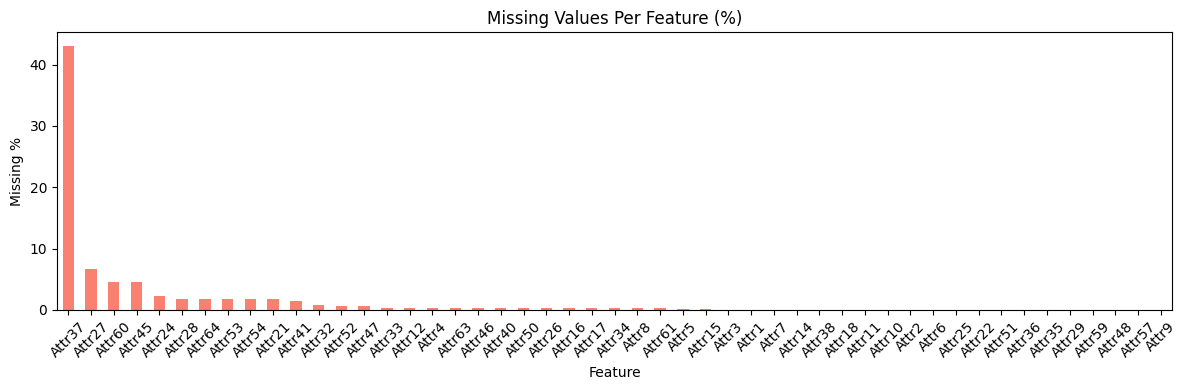

In [10]:
# --- Check missing values ---
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)

print('Columns with missing values:')
print(missing_df)
print(f'\nTotal missing values: {df.isnull().sum().sum()}')

# Plot missing values
plt.figure(figsize=(12, 4))
missing_df['Missing %'].plot(kind='bar', color='salmon')
plt.title('Missing Values Per Feature (%)')
plt.ylabel('Missing %')
plt.xlabel('Feature')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [11]:
# --- Strategy: Drop columns with >40% missing, fill rest with median ---

# Drop high-missing columns
threshold = 40
cols_to_drop = missing_df[missing_df['Missing %'] > threshold].index.tolist()
print(f'Dropping columns with >{threshold}% missing: {cols_to_drop}')
df_clean = df.drop(columns=cols_to_drop)

# Fill remaining missing values with column median
# Median is more robust than mean for financial data (handles outliers)
df_clean = df_clean.fillna(df_clean.median(numeric_only=True))

print(f'\nShape after cleaning: {df_clean.shape}')
print(f'Remaining missing values: {df_clean.isnull().sum().sum()}')

Dropping columns with >40% missing: ['Attr37']

Shape after cleaning: (5910, 64)
Remaining missing values: 0


In [12]:
# --- Handle extreme outliers using IQR capping ---
# Cap outliers at 1st and 99th percentile (Winsorization)

X_raw = df_clean.drop('class', axis=1)
y = df_clean['class']

for col in X_raw.columns:
    p1  = X_raw[col].quantile(0.01)
    p99 = X_raw[col].quantile(0.99)
    X_raw[col] = X_raw[col].clip(lower=p1, upper=p99)

print('✅ Outlier capping complete (1st-99th percentile)')
print(f'Features available: {X_raw.shape[1]}')

✅ Outlier capping complete (1st-99th percentile)
Features available: 63


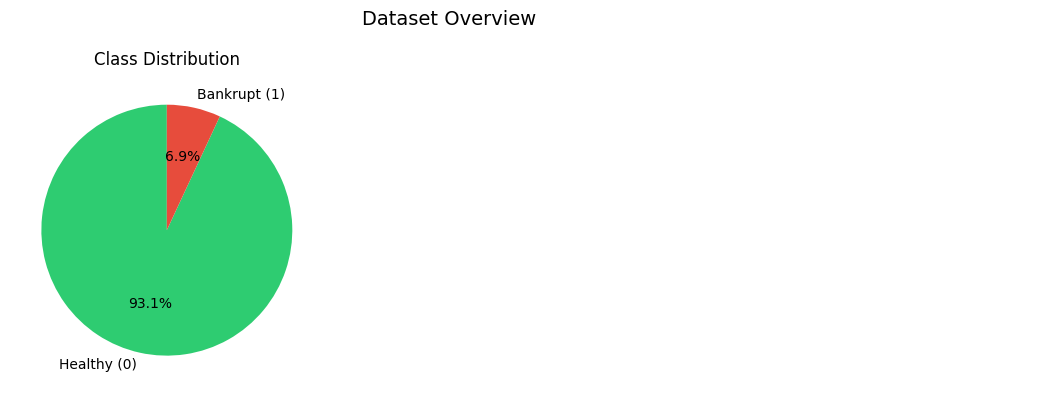

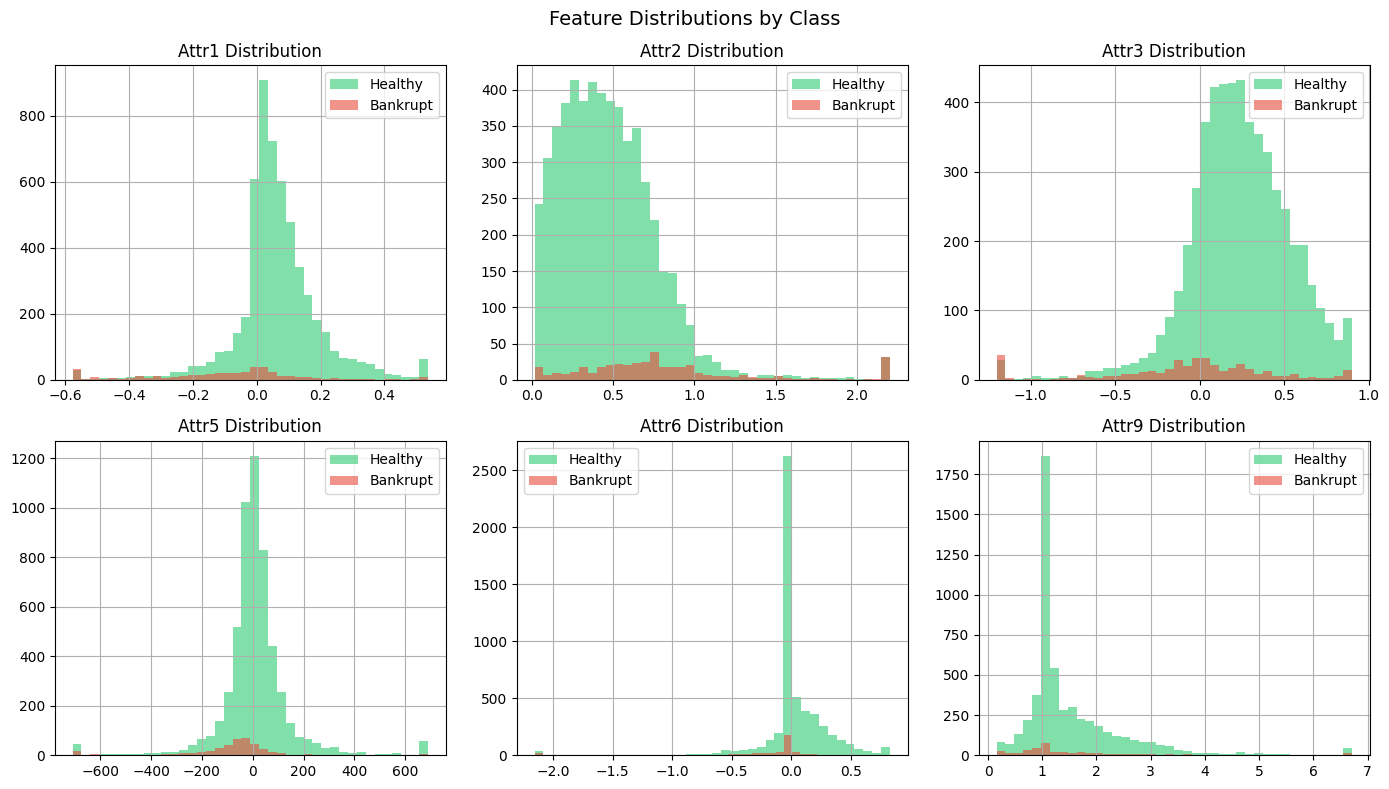

In [13]:
# Class distribution pie chart
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Pie chart
y.value_counts().plot.pie(
    ax=axes[0],
    labels=['Healthy (0)', 'Bankrupt (1)'],
    autopct='%1.1f%%',
    colors=['#2ecc71', '#e74c3c'],
    startangle=90
)
axes[0].set_title('Class Distribution')
axes[0].set_ylabel('')

# Feature distributions for first 6 features split by class
axes[1].axis('off')
fig.suptitle('Dataset Overview', fontsize=14)
plt.tight_layout()
plt.show()

# Distribution of key financial features by class
key_features = ['Attr1', 'Attr2', 'Attr3', 'Attr5', 'Attr6', 'Attr9']
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, feat in enumerate(key_features):
    if feat in X_raw.columns:
        X_raw[y==0][feat].hist(ax=axes[i], bins=40, alpha=0.6, color='#2ecc71', label='Healthy')
        X_raw[y==1][feat].hist(ax=axes[i], bins=40, alpha=0.6, color='#e74c3c', label='Bankrupt')
        axes[i].set_title(f'{feat} Distribution')
        axes[i].legend()

plt.suptitle('Feature Distributions by Class', fontsize=14)
plt.tight_layout()
plt.show()

✅ Features scaled with StandardScaler

Features reduced: 63 → 20

Top 20 selected features:
['Attr39', 'Attr35', 'Attr27', 'Attr46', 'Attr24', 'Attr22', 'Attr42', 'Attr21', 'Attr41', 'Attr56', 'Attr34', 'Attr58', 'Attr29', 'Attr40', 'Attr18', 'Attr1', 'Attr14', 'Attr55', 'Attr15', 'Attr26']


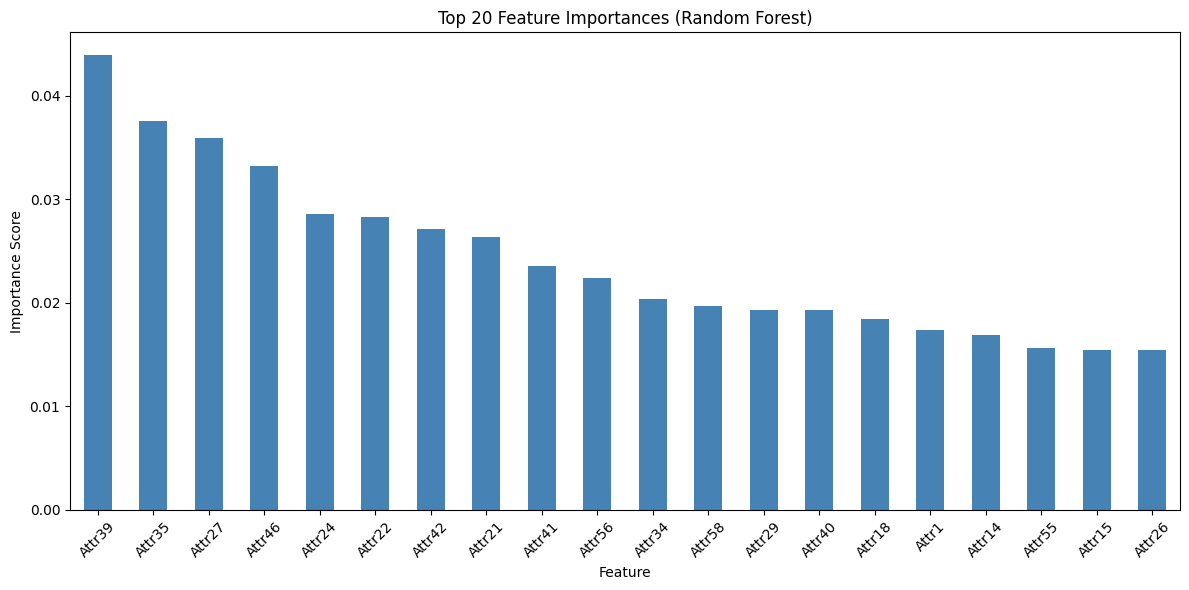

In [14]:
# --- Scale features ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)
X_scaled = pd.DataFrame(X_scaled, columns=X_raw.columns)

print('✅ Features scaled with StandardScaler')

# --- Feature Selection using Random Forest importance ---
rf_selector = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_selector.fit(X_scaled, y)

# Get feature importances
importances = pd.Series(rf_selector.feature_importances_, index=X_raw.columns)
importances = importances.sort_values(ascending=False)

# Select top 20 features
top_features = importances.head(20).index.tolist()
X_selected = X_scaled[top_features]

print(f'\nFeatures reduced: {X_scaled.shape[1]} → {X_selected.shape[1]}')
print('\nTop 20 selected features:')
print(top_features)

# Plot feature importances
plt.figure(figsize=(12, 6))
importances.head(20).plot(kind='bar', color='steelblue')
plt.title('Top 20 Feature Importances (Random Forest)')
plt.ylabel('Importance Score')
plt.xlabel('Feature')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [15]:
# Split data BEFORE applying SMOTE (important: only apply SMOTE to training data)
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y, test_size=0.2, random_state=42, stratify=y
)

print('Before SMOTE:')
print(f'  Training set: {X_train.shape[0]} samples')
print(f'  Class distribution: {dict(y_train.value_counts())}')

# Apply SMOTE only to training data
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print('\nAfter SMOTE:')
print(f'  Training set: {X_train_res.shape[0]} samples')
print(f'  Class distribution: {dict(pd.Series(y_train_res).value_counts())}')
print(f'\n  Test set (untouched): {X_test.shape[0]} samples')

Before SMOTE:
  Training set: 4728 samples
  Class distribution: {0: np.int64(4400), 1: np.int64(328)}

After SMOTE:
  Training set: 8800 samples
  Class distribution: {0: np.int64(4400), 1: np.int64(4400)}

  Test set (untouched): 1182 samples


In [16]:
# Define 3 models to compare
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'XGBoost':             XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss', verbosity=0)
}

results = {}

for name, model in models.items():
    model.fit(X_train_res, y_train_res)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    results[name] = {
        'model':  model,
        'y_pred': y_pred,
        'y_prob': y_prob,
        'f1':     f1_score(y_test, y_pred, average='weighted'),
        'roc_auc': roc_auc_score(y_test, y_prob)
    }
    print(f'\n📌 {name}')
    print(f'   F1 Score : {results[name]["f1"]:.4f}')
    print(f'   ROC-AUC  : {results[name]["roc_auc"]:.4f}')


📌 Logistic Regression
   F1 Score : 0.8379
   ROC-AUC  : 0.8432

📌 Random Forest
   F1 Score : 0.9338
   ROC-AUC  : 0.9292

📌 XGBoost
   F1 Score : 0.9501
   ROC-AUC  : 0.9533


🏆 Best Model: XGBoost

Classification Report:
              precision    recall  f1-score   support

     Healthy       0.98      0.96      0.97      1100
    Bankrupt       0.59      0.78      0.67        82

    accuracy                           0.95      1182
   macro avg       0.79      0.87      0.82      1182
weighted avg       0.96      0.95      0.95      1182



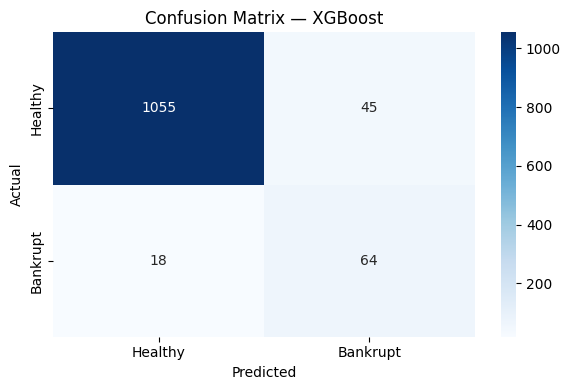

In [17]:
# --- Detailed report for best model (XGBoost typically best) ---
best_model_name = max(results, key=lambda x: results[x]['roc_auc'])
print(f'🏆 Best Model: {best_model_name}')
print('\nClassification Report:')
print(classification_report(y_test, results[best_model_name]['y_pred'],  target_names=['Healthy', 'Bankrupt']))

# Confusion matrix
cm = confusion_matrix(y_test, results[best_model_name]['y_pred'])
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Healthy', 'Bankrupt'],
            yticklabels=['Healthy', 'Bankrupt'])
plt.title(f'Confusion Matrix — {best_model_name}')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

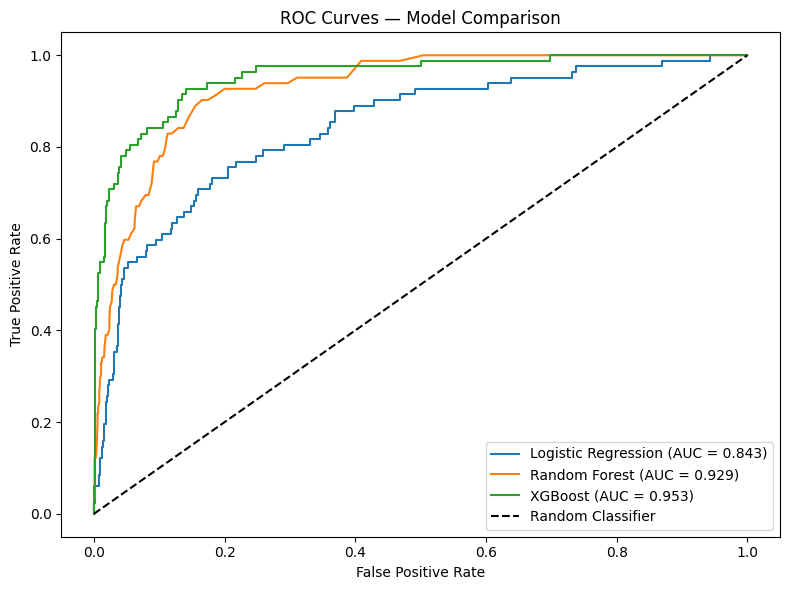

In [18]:
# --- ROC Curves for all models ---
plt.figure(figsize=(8, 6))

for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    plt.plot(fpr, tpr, label=f"{name} (AUC = {res['roc_auc']:.3f})")

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — Model Comparison')
plt.legend()
plt.tight_layout()
plt.show()

In [19]:
# Use the best model for SHAP explanations
best_model = results[best_model_name]['model']

# Create SHAP explainer
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)

# For binary classification, use values for class 1 (Bankrupt)
if isinstance(shap_values, list):
    sv = shap_values[1]  # Random Forest returns list
else:
    sv = shap_values     # XGBoost returns array

print(f'✅ SHAP values computed for {best_model_name}')
print(f'   SHAP array shape: {sv.shape}')

✅ SHAP values computed for XGBoost
   SHAP array shape: (1182, 20)


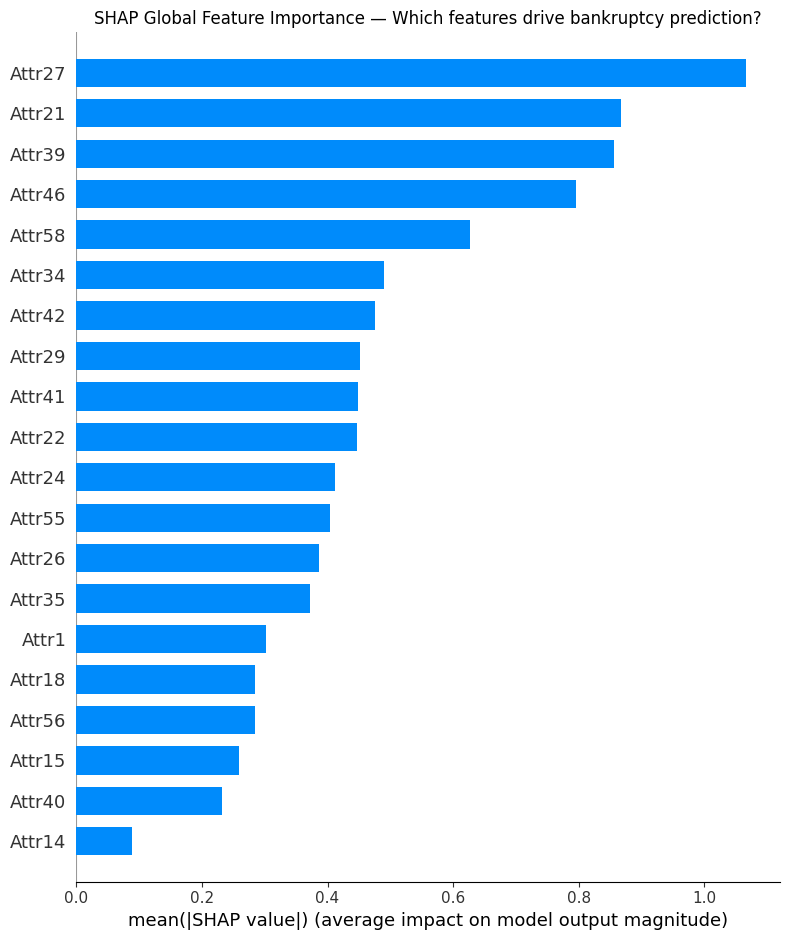

In [20]:
# --- SHAP Summary Plot (Global Feature Importance) ---
# Shows which features matter most ACROSS ALL predictions
plt.figure(figsize=(10, 7))
shap.summary_plot(sv, X_test, plot_type='bar', show=False)
plt.title('SHAP Global Feature Importance — Which features drive bankruptcy prediction?')
plt.tight_layout()
plt.show()

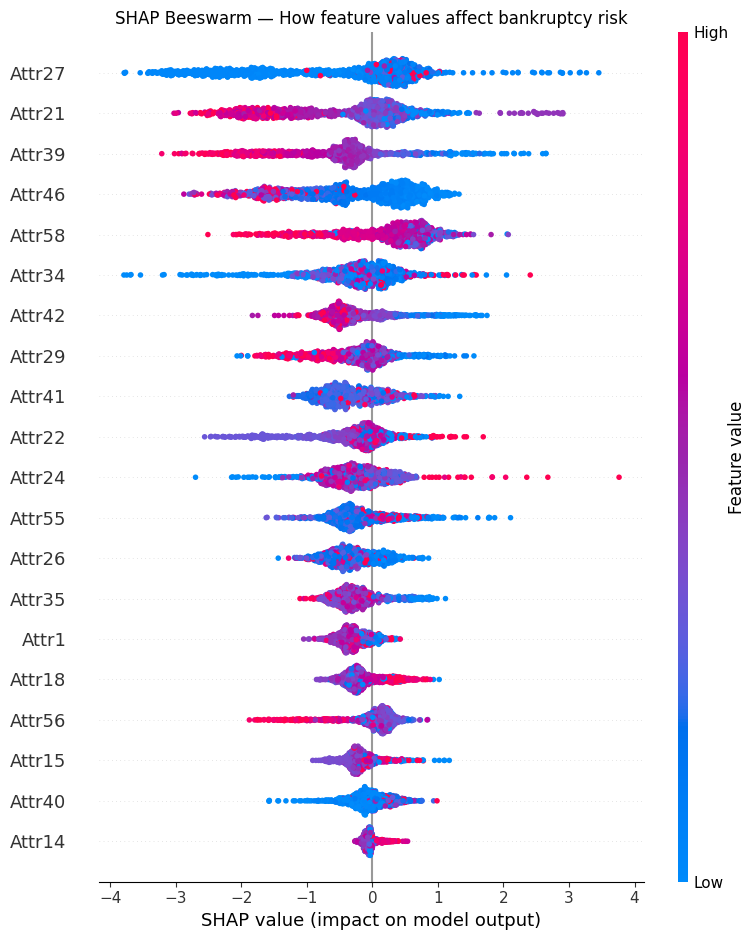

In [21]:
# --- SHAP Beeswarm Plot (Direction of Impact) ---
# Shows HOW each feature pushes predictions toward healthy or bankrupt
# Red = high feature value, Blue = low feature value
plt.figure(figsize=(10, 7))
shap.summary_plot(sv, X_test, show=False)
plt.title('SHAP Beeswarm — How feature values affect bankruptcy risk')
plt.tight_layout()
plt.show()

Explaining prediction for test sample index: 17
True label: Bankrupt
Predicted:  Bankrupt


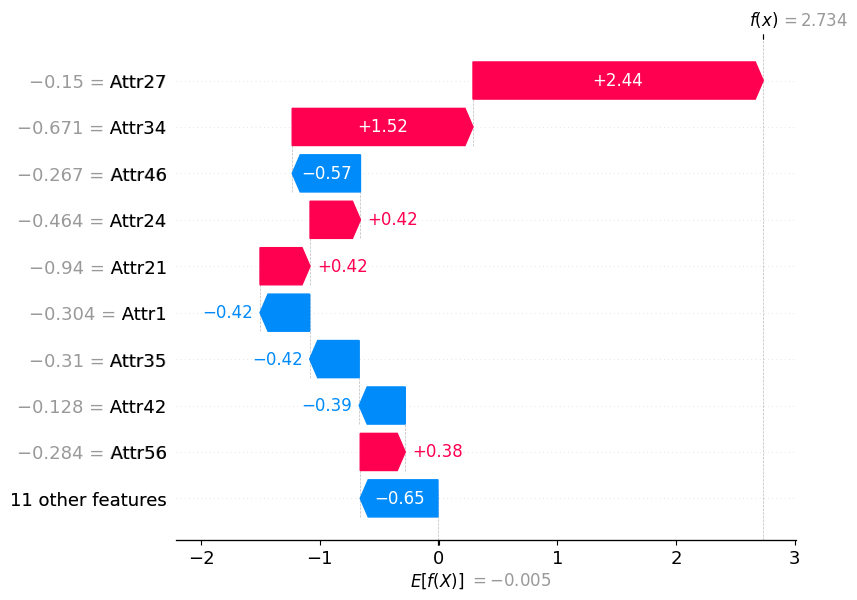

In [22]:
# --- SHAP Waterfall Plot (Single Prediction Explanation) ---
# Explains WHY the model made a specific prediction for one company

# Pick a bankrupt company from test set to explain
bankrupt_idx = np.where(y_test.values == 1)[0]
if len(bankrupt_idx) > 0:
    sample_idx = bankrupt_idx[0]
    print(f'Explaining prediction for test sample index: {sample_idx}')
    print(f'True label: {"Bankrupt" if y_test.values[sample_idx] == 1 else "Healthy"}')
    print(f'Predicted:  {"Bankrupt" if results[best_model_name]["y_pred"][sample_idx] == 1 else "Healthy"}')
    
    # Waterfall plot
    shap_exp = shap.Explanation(
        values=sv[sample_idx],
        base_values=explainer.expected_value if not isinstance(explainer.expected_value, list)
                    else explainer.expected_value[1],
        data=X_test.iloc[sample_idx].values,
        feature_names=X_test.columns.tolist()
    )
    shap.waterfall_plot(shap_exp, show=True)

In [23]:
# --- SHAP Force Plot (Interactive HTML — works in Jupyter) ---
shap.initjs()
force_plot = shap.force_plot(
    explainer.expected_value if not isinstance(explainer.expected_value, list)
    else explainer.expected_value[1],
    sv[sample_idx],
    X_test.iloc[sample_idx],
    feature_names=X_test.columns.tolist()
)
force_plot

In [24]:
print('=' * 55)
print('         BANKRUPTCY PREDICTION — FINAL SUMMARY')
print('=' * 55)
print(f'Dataset       : Polish Companies 5year.arff')
print(f'Samples       : {df.shape[0]} companies')
print(f'Features used : {X_selected.shape[1]} (selected from {X_raw.shape[1]})')
print(f'Class balance : {dict(y.value_counts())}')
print(f'Imbalance fix : SMOTE oversampling')
print('-' * 55)
print('Model Performance on Test Set:')
for name, res in results.items():
    marker = ' 🏆' if name == best_model_name else ''
    print(f'  {name:<25} F1={res["f1"]:.4f}  AUC={res["roc_auc"]:.4f}{marker}')
print('-' * 55)
print(f'Best Model    : {best_model_name}')
print(f'XAI Method    : SHAP (TreeExplainer)')
print('=' * 55)

         BANKRUPTCY PREDICTION — FINAL SUMMARY
Dataset       : Polish Companies 5year.arff
Samples       : 5910 companies
Features used : 20 (selected from 63)
Class balance : {0: np.int64(5500), 1: np.int64(410)}
Imbalance fix : SMOTE oversampling
-------------------------------------------------------
Model Performance on Test Set:
  Logistic Regression       F1=0.8379  AUC=0.8432
  Random Forest             F1=0.9338  AUC=0.9292
  XGBoost                   F1=0.9501  AUC=0.9533 🏆
-------------------------------------------------------
Best Model    : XGBoost
XAI Method    : SHAP (TreeExplainer)
